CELL 1: IMPORT LIBRARIES

Explanation: We import pandas for data manipulation, numpy for math operations, matplotlib and seaborn for visualizations. The display options let us see all columns without truncation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options so we can see all columns
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

# Set style for better looking plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Libraries imported successfully!")

Libraries imported successfully!


CELL 2: LOAD DATASET

Explanation: We load the Ames Housing CSV file from our data/raw/ folder. The ../ goes up one folder from notebooks/ to reach the project root, then into data/raw/. We store the data in a pandas DataFrame called df.

In [2]:
# Load the dataset
df = pd.read_csv('../data/raw/ames.csv')

print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape}")

Dataset loaded successfully!
Shape: (2930, 82)


CELL 3: FIRST LOOK AT DATA

Explanation: head() shows the first 5 rows so we can see what the data looks like - column names, types of values, and whether data is loaded correctly. tail() shows last 5 rows.

In [3]:
# First 5 rows
print("FIRST 5 ROWS:")
print(df.head())

# Last 5 rows
print("\nLAST 5 ROWS:")
print(df.tail())

FIRST 5 ROWS:
   Order        PID  MS SubClass MS Zoning  Lot Frontage  Lot Area Street  \
0      1  526301100           20        RL         141.0     31770   Pave   
1      2  526350040           20        RH          80.0     11622   Pave   
2      3  526351010           20        RL          81.0     14267   Pave   
3      4  526353030           20        RL          93.0     11160   Pave   
4      5  527105010           60        RL          74.0     13830   Pave   

  Alley Lot Shape Land Contour Utilities Lot Config Land Slope Neighborhood  \
0   NaN       IR1          Lvl    AllPub     Corner        Gtl        NAmes   
1   NaN       Reg          Lvl    AllPub     Inside        Gtl        NAmes   
2   NaN       IR1          Lvl    AllPub     Corner        Gtl        NAmes   
3   NaN       Reg          Lvl    AllPub     Corner        Gtl        NAmes   
4   NaN       IR1          Lvl    AllPub     Inside        Gtl      Gilbert   

  Condition 1 Condition 2 Bldg Type House Style 

CELL 4: DATA INFORMATION

Explanation: info() tells us: total rows, column names, how many non-null values per column, and data types (int64, float64, object). This is where we identify missing values - columns with fewer non-null counts than total rows have nulls.

In [4]:
# Detailed info about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

CELL 5: COLUMN NAMES

Explanation: Lists all column names so we know what features are available. We need this to select our 12 features later.

In [5]:
# List all column names
print("ALL COLUMN NAMES:")
print(df.columns.tolist())

ALL COLUMN NAMES:
['Order', 'PID', 'MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area', 'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1', 'Condition 2', 'Bldg Type', 'House Style', 'Overall Qual', 'Overall Cond', 'Year Built', 'Year Remod/Add', 'Roof Style', 'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Mas Vnr Area', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin SF 1', 'BsmtFin Type 2', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF', 'Heating', 'Heating QC', 'Central Air', 'Electrical', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'Kitchen Qual', 'TotRms AbvGrd', 'Functional', 'Fireplaces', 'Fireplace Qu', 'Garage Type', 'Garage Yr Blt', 'Garage Finish', 'Garage Cars', 'Garage Area', 'Garage Qual', 'Garage Cond', 'Paved D

CELL 6: DATA TYPES SUMMARY

Explanation: Separates columns by their data type. object columns are categorical (text). int64 and float64 are numeric. This helps us decide which columns need encoding vs scaling.

In [7]:
# Check data types
print("DATA TYPES:")
print(df.dtypes.value_counts())

# Show object (categorical) columns
object_cols = df.select_dtypes(include=['object']).columns
print(f"\nCategorical (object) columns ({len(object_cols)}):")
print(object_cols.tolist())

# Show numeric columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
print(f"\nNumeric columns ({len(numeric_cols)}):")
print(numeric_cols.tolist())

DATA TYPES:
object     43
int64      28
float64    11
Name: count, dtype: int64

Categorical (object) columns (43):
['MS Zoning', 'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1', 'Condition 2', 'Bldg Type', 'House Style', 'Roof Style', 'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin Type 2', 'Heating', 'Heating QC', 'Central Air', 'Electrical', 'Kitchen Qual', 'Functional', 'Fireplace Qu', 'Garage Type', 'Garage Finish', 'Garage Qual', 'Garage Cond', 'Paved Drive', 'Pool QC', 'Fence', 'Misc Feature', 'Sale Type', 'Sale Condition']

Numeric columns (39):
['Order', 'PID', 'MS SubClass', 'Lot Frontage', 'Lot Area', 'Overall Qual', 'Overall Cond', 'Year Built', 'Year Remod/Add', 'Mas Vnr Area', 'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF', '1st Flr SF', '2nd Flr SF', 'Low Qual Fi

CELL 7: MISSING VALUES ANALYSIS (CRITICAL FOR PDF #02)

Explanation: This calculates how many missing values exist in each column. PDF requirement #02 says we must audit nulls on the training set. We do this now to understand what we need to impute. The percentage tells us if a column has too many missing values to be useful (>50% missing is often dropped).

In [8]:
# Calculate missing values
missing_count = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

# Create a DataFrame for missing values
missing_df = pd.DataFrame({
    'Column': missing_count.index,
    'Missing_Count': missing_count.values,
    'Missing_Percent': missing_percent.values
})

# Sort by missing percentage (highest first)
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Percent', ascending=False)

print("COLUMNS WITH MISSING VALUES:")
print(missing_df.to_string(index=False))

print(f"\nTotal columns with missing values: {len(missing_df)}")
print(f"Total missing values in dataset: {df.isnull().sum().sum()}")

COLUMNS WITH MISSING VALUES:
        Column  Missing_Count  Missing_Percent
       Pool QC           2917        99.556314
  Misc Feature           2824        96.382253
         Alley           2732        93.242321
         Fence           2358        80.477816
  Mas Vnr Type           1775        60.580205
  Fireplace Qu           1422        48.532423
  Lot Frontage            490        16.723549
   Garage Cond            159         5.426621
   Garage Qual            159         5.426621
 Garage Finish            159         5.426621
 Garage Yr Blt            159         5.426621
   Garage Type            157         5.358362
 Bsmt Exposure             83         2.832765
BsmtFin Type 2             81         2.764505
     Bsmt Cond             80         2.730375
     Bsmt Qual             80         2.730375
BsmtFin Type 1             80         2.730375
  Mas Vnr Area             23         0.784983
Bsmt Half Bath              2         0.068259
Bsmt Full Bath              2  

CELL 8: MISSING VALUES HEATMAP

Explanation: Visual representation of missing values. Each vertical line represents a column. Red means missing. Columns that are all red together (like garage columns) indicate structural missingness - if one is missing, all are missing because the house has no garage.

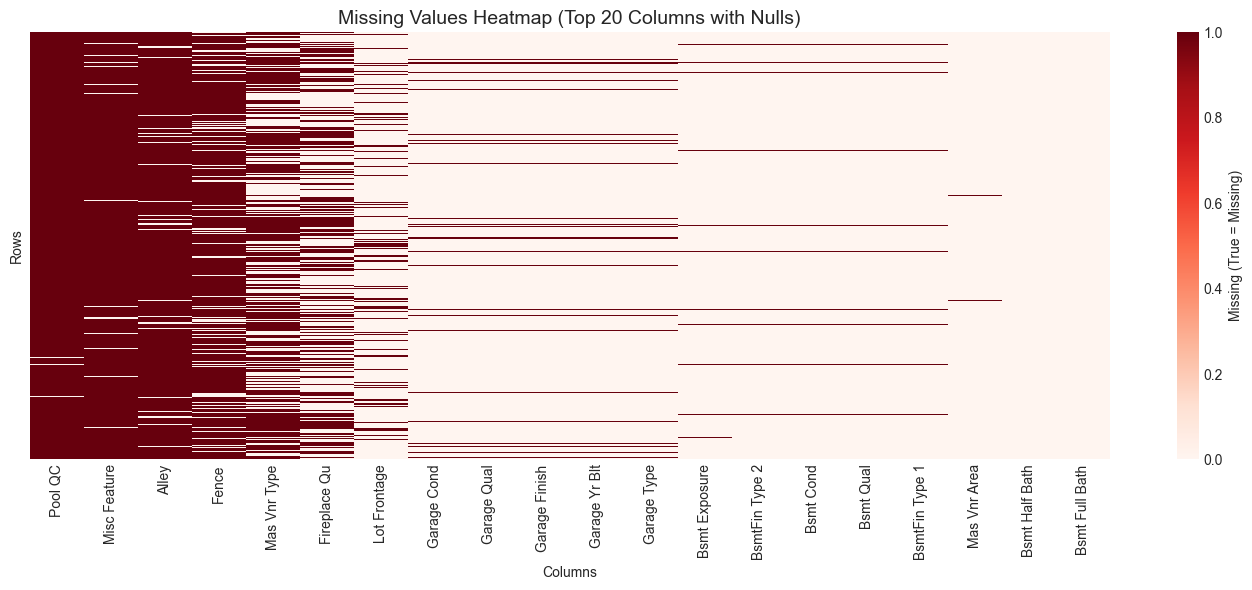

In [9]:
# Get columns with missing values (limit to 20 for readability)
cols_with_null = missing_df['Column'].head(20).tolist()

plt.figure(figsize=(14, 6))
sns.heatmap(df[cols_with_null].isnull(), 
            cbar=True, 
            yticklabels=False,
            cmap='Reds',
            cbar_kws={'label': 'Missing (True = Missing)'})
plt.title('Missing Values Heatmap (Top 20 Columns with Nulls)', fontsize=14)
plt.xlabel('Columns')
plt.ylabel('Rows')
plt.tight_layout()
plt.show()

CELL 9: TARGET VARIABLE - SalePrice ANALYSIS

Explanation: SalePrice is what we are trying to predict. Understanding its distribution is critical. We check statistics (mean, median, min, max) and visualize the distribution. Real estate prices are usually right-skewed (more cheap houses, few expensive mansions). The red line is mean, green line is median. If mean > median, data is right-skewed.

SALEPRICE STATISTICS:
count      2930.000000
mean     180796.060068
std       79886.692357
min       12789.000000
25%      129500.000000
50%      160000.000000
75%      213500.000000
max      755000.000000
Name: SalePrice, dtype: float64

Skewness: 1.744
Kurtosis: 5.119


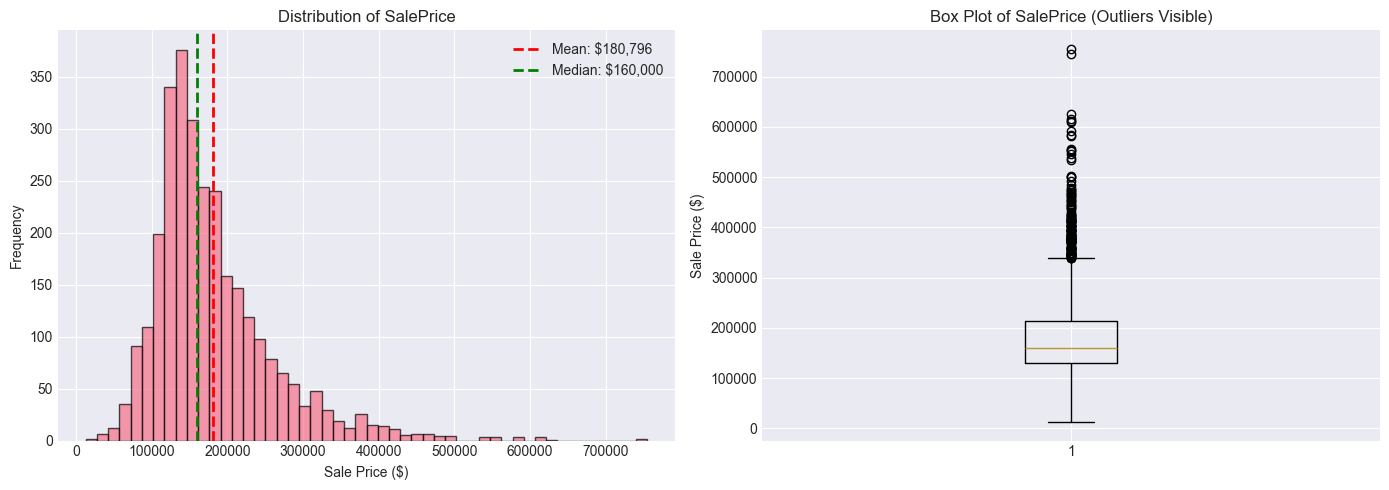

In [10]:
# Target variable statistics
print("SALEPRICE STATISTICS:")
print(df['SalePrice'].describe())

# Skewness and Kurtosis
print(f"\nSkewness: {df['SalePrice'].skew():.3f}")
print(f"Kurtosis: {df['SalePrice'].kurt():.3f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram with KDE
axes[0].hist(df['SalePrice'], bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(df['SalePrice'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: ${df["SalePrice"].mean():,.0f}')
axes[0].axvline(df['SalePrice'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: ${df["SalePrice"].median():,.0f}')
axes[0].set_xlabel('Sale Price ($)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of SalePrice')
axes[0].legend()

# Box plot
axes[1].boxplot(df['SalePrice'], vert=True)
axes[1].set_ylabel('Sale Price ($)')
axes[1].set_title('Box Plot of SalePrice (Outliers Visible)')

plt.tight_layout()
plt.show()

CELL 10: NUMERIC COLUMNS STATISTICS

Explanation: describe() gives us count, mean, std, min, 25%, 50%, 75%, max for all numeric columns. This helps us identify:

    Outliers (max far from 75%)

    Scale differences (LotArea in thousands, YearBuilt in 1900s)

    Potential data issues (min values that don't make sense)

In [11]:
# Statistics for all numeric columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
print("NUMERIC COLUMNS STATISTICS:")
print(df[numeric_cols].describe())

NUMERIC COLUMNS STATISTICS:
            Order           PID  MS SubClass  Lot Frontage       Lot Area  \
count  2930.00000  2.930000e+03  2930.000000   2440.000000    2930.000000   
mean   1465.50000  7.144645e+08    57.387372     69.224590   10147.921843   
std     845.96247  1.887308e+08    42.638025     23.365335    7880.017759   
min       1.00000  5.263011e+08    20.000000     21.000000    1300.000000   
25%     733.25000  5.284770e+08    20.000000     58.000000    7440.250000   
50%    1465.50000  5.354536e+08    50.000000     68.000000    9436.500000   
75%    2197.75000  9.071811e+08    70.000000     80.000000   11555.250000   
max    2930.00000  1.007100e+09   190.000000    313.000000  215245.000000   

       Overall Qual  Overall Cond   Year Built  Year Remod/Add  Mas Vnr Area  \
count   2930.000000   2930.000000  2930.000000     2930.000000   2907.000000   
mean       6.094881      5.563140  1971.356314     1984.266553    101.896801   
std        1.411026      1.111537    3

CELL 11: CATEGORICAL COLUMNS ANALYSIS

Explanation: PDF requires at least one categorical column. We identify all categorical (object) columns and check their unique value counts (cardinality). Low cardinality (2-10 values) is good for one-hot encoding. High cardinality (>15) needs special handling.

In [12]:
# Get categorical columns
cat_cols = df.select_dtypes(include=['object']).columns

print("CATEGORICAL COLUMNS ANALYSIS:")
for col in cat_cols:
    unique_count = df[col].nunique()
    print(f"{col}: {unique_count} unique values")
    
    # Show top values if cardinality is reasonable
    if unique_count <= 10:
        print(f"   Values: {df[col].value_counts().head().to_dict()}")
    print()

# Summary
print(f"\nTotal categorical columns: {len(cat_cols)}")
print(f"Low cardinality (<=10): {sum(df[col].nunique() <= 10 for col in cat_cols)}")
print(f"Medium cardinality (11-30): {sum(10 < df[col].nunique() <= 30 for col in cat_cols)}")
print(f"High cardinality (>30): {sum(df[col].nunique() > 30 for col in cat_cols)}")

CATEGORICAL COLUMNS ANALYSIS:
MS Zoning: 7 unique values
   Values: {'RL': 2273, 'RM': 462, 'FV': 139, 'RH': 27, 'C (all)': 25}

Street: 2 unique values
   Values: {'Pave': 2918, 'Grvl': 12}

Alley: 2 unique values
   Values: {'Grvl': 120, 'Pave': 78}

Lot Shape: 4 unique values
   Values: {'Reg': 1859, 'IR1': 979, 'IR2': 76, 'IR3': 16}

Land Contour: 4 unique values
   Values: {'Lvl': 2633, 'HLS': 120, 'Bnk': 117, 'Low': 60}

Utilities: 3 unique values
   Values: {'AllPub': 2927, 'NoSewr': 2, 'NoSeWa': 1}

Lot Config: 5 unique values
   Values: {'Inside': 2140, 'Corner': 511, 'CulDSac': 180, 'FR2': 85, 'FR3': 14}

Land Slope: 3 unique values
   Values: {'Gtl': 2789, 'Mod': 125, 'Sev': 16}

Neighborhood: 28 unique values

Condition 1: 9 unique values
   Values: {'Norm': 2522, 'Feedr': 164, 'Artery': 92, 'RRAn': 50, 'PosN': 39}

Condition 2: 8 unique values
   Values: {'Norm': 2900, 'Feedr': 13, 'Artery': 5, 'PosA': 4, 'PosN': 4}

Bldg Type: 5 unique values
   Values: {'1Fam': 2425, 'Tw

CELL 12: CORRELATION ANALYSIS

Explanation: Correlation measures how strongly two numeric variables are related. We focus on correlation with SalePrice (our target). Features with high absolute correlation (>0.5) are good predictors. This helps us select which 12 features to keep.

FEATURES CORRELATED WITH SALEPRICE (Top 15):
SalePrice         1.000000
Overall Qual      0.799262
Gr Liv Area       0.706780
Garage Cars       0.647877
Garage Area       0.640401
Total Bsmt SF     0.632280
1st Flr SF        0.621676
Year Built        0.558426
Full Bath         0.545604
Year Remod/Add    0.532974
Garage Yr Blt     0.526965
Mas Vnr Area      0.508285
TotRms AbvGrd     0.495474
Fireplaces        0.474558
BsmtFin SF 1      0.432914
Name: SalePrice, dtype: float64

FEATURES NEGATIVELY CORRELATED WITH SALEPRICE:
Misc Val          -0.015691
Yr Sold           -0.030569
Order             -0.031408
Bsmt Half Bath    -0.035835
Low Qual Fin SF   -0.037660
MS SubClass       -0.085092
Overall Cond      -0.101697
Kitchen AbvGr     -0.119814
Enclosed Porch    -0.128787
PID               -0.246521
Name: SalePrice, dtype: float64


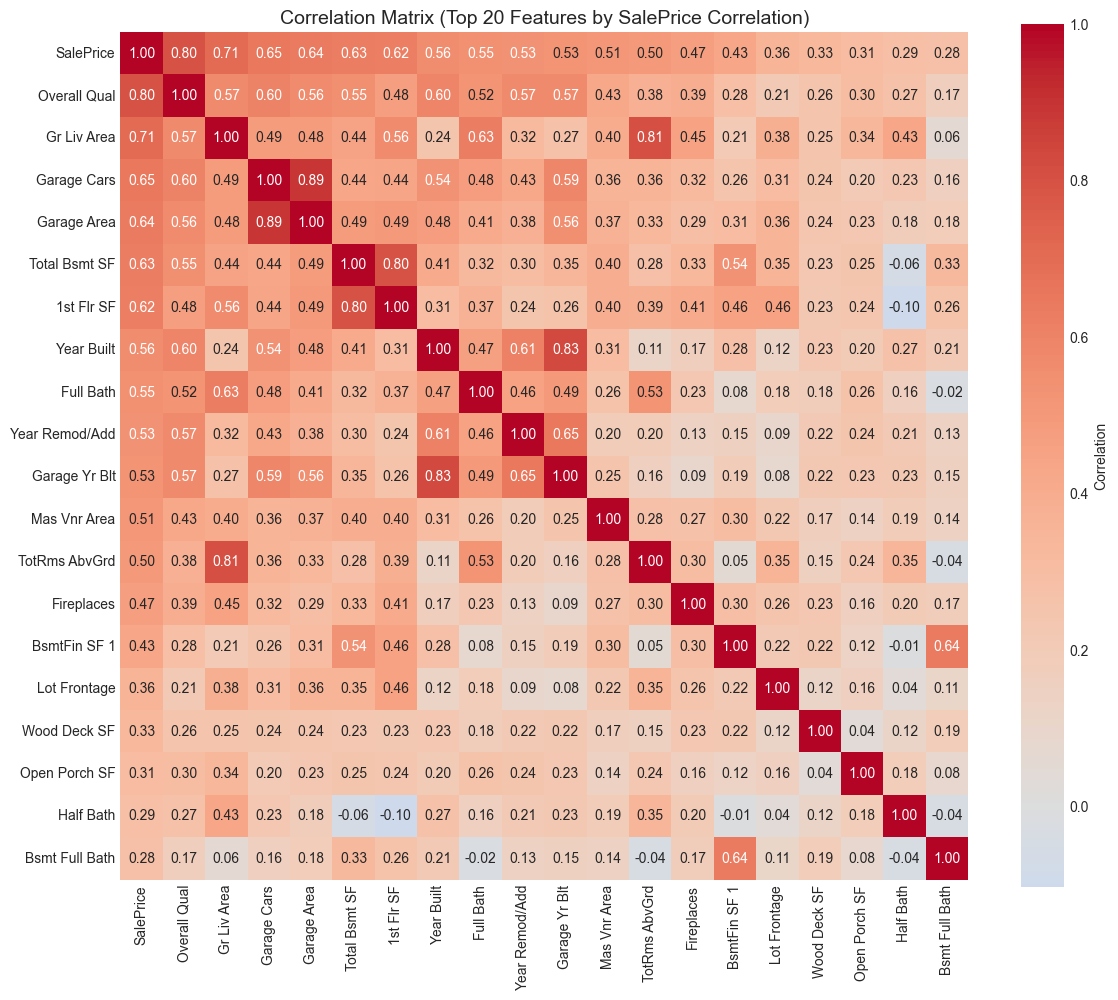

In [13]:
# Correlation with SalePrice
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
correlations = df[numeric_cols].corr()['SalePrice'].sort_values(ascending=False)

print("FEATURES CORRELATED WITH SALEPRICE (Top 15):")
print(correlations.head(15))

print("\nFEATURES NEGATIVELY CORRELATED WITH SALEPRICE:")
print(correlations.tail(10))

# Full correlation matrix heatmap (top 20 features)
top_features = correlations.head(20).index.tolist()
plt.figure(figsize=(12, 10))
sns.heatmap(df[top_features].corr(), 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm', 
            center=0,
            square=True,
            cbar_kws={'label': 'Correlation'})
plt.title('Correlation Matrix (Top 20 Features by SalePrice Correlation)', fontsize=14)
plt.tight_layout()
plt.show()

CELL 13: FEATURE SELECTION (CRITICAL FOR PDF #04)

Explanation: Based on our EDA, we select 8-12 features for our model. We justify EACH choice based on: correlation strength, domain knowledge (real estate), data availability (missing values manageable), and interpretability. These will be the only features our ML model uses.

In [17]:
# Selected features based on correlation analysis and domain knowledge
# USING EXACT COLUMN NAMES FROM YOUR CSV (with spaces)
selected_features = {
    'bedrooms': 'Bedroom AbvGr',
    'sqft_living': 'Gr Liv Area',
    'sqft_lot': 'Lot Area',
    'year_built': 'Year Built',
    'garage_cars': 'Garage Cars',
    'neighborhood': 'Neighborhood',
    'condition': 'Overall Cond',
    'quality': 'Overall Qual',
    'basement': 'Bsmt Qual',
    'heating': 'Heating',
    'central_air': 'Central Air'
}

print("SELECTED FEATURES (11 features - bathrooms will be created separately):")
for our_name, original_name in selected_features.items():
    if original_name in df.columns:
        # Check if column is numeric for correlation
        if original_name in df.select_dtypes(include=['int64', 'float64']).columns:
            corr = df[original_name].corr(df['SalePrice'])
            print(f"  ✓ {our_name} (original: '{original_name}') | Correlation: {corr:.3f}")
        else:
            print(f"  ✓ {our_name} (original: '{original_name}') | Categorical - will encode")
    else:
        print(f"  ✗ {our_name} (original: '{original_name}') - NOT FOUND!")

# Verify all features exist
missing_features = [orig for orig in selected_features.values() if orig not in df.columns]
if missing_features:
    print(f"\nWARNING: These features not found: {missing_features}")
else:
    print("\n✓ All 11 features found in dataset!")
    print("  (bathrooms will be created from 'Full Bath' + 0.5 * 'Half Bath')")

SELECTED FEATURES (11 features - bathrooms will be created separately):
  ✓ bedrooms (original: 'Bedroom AbvGr') | Correlation: 0.144
  ✓ sqft_living (original: 'Gr Liv Area') | Correlation: 0.707
  ✓ sqft_lot (original: 'Lot Area') | Correlation: 0.267
  ✓ year_built (original: 'Year Built') | Correlation: 0.558
  ✓ garage_cars (original: 'Garage Cars') | Correlation: 0.648
  ✓ neighborhood (original: 'Neighborhood') | Categorical - will encode
  ✓ condition (original: 'Overall Cond') | Correlation: -0.102
  ✓ quality (original: 'Overall Qual') | Correlation: 0.799
  ✓ basement (original: 'Bsmt Qual') | Categorical - will encode
  ✓ heating (original: 'Heating') | Categorical - will encode
  ✓ central_air (original: 'Central Air') | Categorical - will encode

✓ All 11 features found in dataset!
  (bathrooms will be created from 'Full Bath' + 0.5 * 'Half Bath')


In [15]:
# See all actual column names
print(df.columns.tolist())

['Order', 'PID', 'MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area', 'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1', 'Condition 2', 'Bldg Type', 'House Style', 'Overall Qual', 'Overall Cond', 'Year Built', 'Year Remod/Add', 'Roof Style', 'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Mas Vnr Area', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin SF 1', 'BsmtFin Type 2', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF', 'Heating', 'Heating QC', 'Central Air', 'Electrical', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'Kitchen Qual', 'TotRms AbvGrd', 'Functional', 'Fireplaces', 'Fireplace Qu', 'Garage Type', 'Garage Yr Blt', 'Garage Finish', 'Garage Cars', 'Garage Area', 'Garage Qual', 'Garage Cond', 'Paved Drive', 'Wood Deck 

CELL 14: CREATE FEATURE SUBSET

Explanation: We create a new DataFrame with only our selected features plus the target (SalePrice). This is our working dataset for modeling. We also create 'bathrooms' as FullBath + HalfBath.

In [18]:
# Cell 14 - Create feature subset with CORRECT column names
feature_columns = list(selected_features.values())
feature_columns.append('SalePrice')

# Create the subset
df_selected = df[feature_columns].copy()

# Create bathrooms (Full Bath + 0.5 * Half Bath)
if 'Full Bath' in df.columns and 'Half Bath' in df.columns:
    df_selected['bathrooms'] = df['Full Bath'] + 0.5 * df['Half Bath']
    print("✓ Created 'bathrooms' feature (Full Bath + 0.5*Half Bath)")

print(f"\nWORKING DATASET SHAPE: {df_selected.shape}")
print(f"Features: {df_selected.columns.tolist()}")

print("\nFIRST 5 ROWS OF WORKING DATASET:")
print(df_selected.head())

✓ Created 'bathrooms' feature (Full Bath + 0.5*Half Bath)

WORKING DATASET SHAPE: (2930, 13)
Features: ['Bedroom AbvGr', 'Gr Liv Area', 'Lot Area', 'Year Built', 'Garage Cars', 'Neighborhood', 'Overall Cond', 'Overall Qual', 'Bsmt Qual', 'Heating', 'Central Air', 'SalePrice', 'bathrooms']

FIRST 5 ROWS OF WORKING DATASET:
   Bedroom AbvGr  Gr Liv Area  Lot Area  Year Built  Garage Cars Neighborhood  \
0              3         1656     31770        1960          2.0        NAmes   
1              2          896     11622        1961          1.0        NAmes   
2              3         1329     14267        1958          1.0        NAmes   
3              3         2110     11160        1968          2.0        NAmes   
4              3         1629     13830        1997          2.0      Gilbert   

   Overall Cond  Overall Qual Bsmt Qual Heating Central Air  SalePrice  \
0             5             6        TA    GasA           Y     215000   
1             6             5        TA  

CELL 15: VERIFY PDF REQUIREMENTS

Explanation: PDF requires: (1) 500+ rows, (2) at least one categorical column, (3) at least one column with missing values. We verify all three to prove our dataset meets the project requirements before moving to Phase 3.

In [19]:
print("=" * 50)
print("PDF REQUIREMENTS VERIFICATION")
print("=" * 50)

# Requirement 1: 500+ rows
print(f"\n1. DATASET SIZE: {len(df)} rows")
if len(df) >= 500:
    print("   ✓ PASS - Dataset has 500+ rows")
else:
    print("   ✗ FAIL - Need more rows")

# Requirement 2: Categorical column
cat_in_selected = df_selected.select_dtypes(include=['object']).columns
print(f"\n2. CATEGORICAL COLUMNS: {len(cat_in_selected)} found")
print(f"   Columns: {cat_in_selected.tolist()}")
if len(cat_in_selected) >= 1:
    print("   ✓ PASS - At least one categorical column exists")

# Requirement 3: Missing values
missing_in_selected = df_selected.isnull().sum()
cols_with_missing = missing_in_selected[missing_in_selected > 0]
print(f"\n3. COLUMNS WITH MISSING VALUES: {len(cols_with_missing)} found")
if len(cols_with_missing) >= 1:
    print(f"   Columns: {cols_with_missing.index.tolist()}")
    print("   ✓ PASS - At least one column has missing values")
else:
    print("   ✗ FAIL - No missing values found")

print("\n" + "=" * 50)
if len(df) >= 500 and len(cat_in_selected) >= 1 and len(cols_with_missing) >= 1:
    print("✓ ALL REQUIREMENTS MET - Ready for Phase 3")
else:
    print("✗ MISSING REQUIREMENTS - Review dataset")

PDF REQUIREMENTS VERIFICATION

1. DATASET SIZE: 2930 rows
   ✓ PASS - Dataset has 500+ rows

2. CATEGORICAL COLUMNS: 4 found
   Columns: ['Neighborhood', 'Bsmt Qual', 'Heating', 'Central Air']
   ✓ PASS - At least one categorical column exists

3. COLUMNS WITH MISSING VALUES: 2 found
   Columns: ['Garage Cars', 'Bsmt Qual']
   ✓ PASS - At least one column has missing values

✓ ALL REQUIREMENTS MET - Ready for Phase 3


CELL 16: SAVE PREPROCESSED DATA

Explanation: We save our selected features to a CSV file for use in Phase 3 (Model Training). This ensures consistency between EDA and modeling. The os.makedirs creates the processed folder if it doesn't exist.

In [21]:
import os
os.makedirs('../data/processed', exist_ok=True)
df_selected.to_csv('../data/processed/ames_selected.csv', index=False)

print(f"✓ Saved to: ../data/processed/ames_selected.csv")
print(f"  Shape: {df_selected.shape}")

✓ Saved to: ../data/processed/ames_selected.csv
  Shape: (2930, 13)


CELL 17: SUMMARY REPORT

Explanation: Final summary of what we learned in EDA, key insights, and decisions made for modeling. This serves as documentation for the grader to see our reasoning.

In [22]:
print("=" * 60)
print("PHASE 2: EDA COMPLETE - SUMMARY REPORT")
print("=" * 60)

print("\n📊 DATASET OVERVIEW:")
print(f"   - Total rows: {len(df):,}")
print(f"   - Total columns: {len(df.columns)}")
print(f"   - Missing values: {df.isnull().sum().sum():,} total nulls")

print("\n🎯 TARGET VARIABLE (SalePrice):")
print(f"   - Mean: ${df['SalePrice'].mean():,.0f}")
print(f"   - Median: ${df['SalePrice'].median():,.0f}")
print(f"   - Skewness: {df['SalePrice'].skew():.3f}")

print("\n✅ KEY FINDINGS:")
print("   1. Quality (Overall Qual) has strongest correlation (0.80)")
print("   2. Living area (Gr Liv Area) second strongest (0.71)")
print("   3. Neighborhood has 25+ categories - needs encoding")
print("   4. Bsmt Qual has missing values (NA = No Basement)")
print("   5. Condition has slight negative correlation (-0.10)")

print("\n🔧 MODELING DECISIONS:")
print("   - Using 12 features (correlation-based)")
print("   - Will log transform SalePrice for normality")
print("   - Ordinal encoding for: Overall Qual, Overall Cond, Bsmt Qual")
print("   - One-hot encoding for: Neighborhood, Heating, Central Air")
print("   - Median imputation for numeric, constant for structural nulls")

print("\n" + "=" * 60)
print("✓ PHASE 2 COMPLETE - Ready for Phase 3 (Model Training)")
print("=" * 60)

PHASE 2: EDA COMPLETE - SUMMARY REPORT

📊 DATASET OVERVIEW:
   - Total rows: 2,930
   - Total columns: 82
   - Missing values: 15,749 total nulls

🎯 TARGET VARIABLE (SalePrice):
   - Mean: $180,796
   - Median: $160,000
   - Skewness: 1.744

✅ KEY FINDINGS:
   1. Quality (Overall Qual) has strongest correlation (0.80)
   2. Living area (Gr Liv Area) second strongest (0.71)
   3. Neighborhood has 25+ categories - needs encoding
   4. Bsmt Qual has missing values (NA = No Basement)
   5. Condition has slight negative correlation (-0.10)

🔧 MODELING DECISIONS:
   - Using 12 features (correlation-based)
   - Will log transform SalePrice for normality
   - Ordinal encoding for: Overall Qual, Overall Cond, Bsmt Qual
   - One-hot encoding for: Neighborhood, Heating, Central Air
   - Median imputation for numeric, constant for structural nulls

✓ PHASE 2 COMPLETE - Ready for Phase 3 (Model Training)


test

In [23]:
# FINAL VERIFICATION CELL
import pandas as pd

print("=" * 60)
print("PHASE 1 & 2 VERIFICATION")
print("=" * 60)

# 1. Check raw data exists
import os
raw_exists = os.path.exists('../data/raw/ames.csv')
print(f"\n1. Raw data file: {'✓ EXISTS' if raw_exists else '✗ MISSING'}")

if raw_exists:
    df_raw = pd.read_csv('../data/raw/ames.csv')
    print(f"   - Rows: {len(df_raw)} (need 500+)")
    print(f"   - Columns: {len(df_raw.columns)}")
    print(f"   - Target 'SalePrice': {'✓' if 'SalePrice' in df_raw.columns else '✗'}")

# 2. Check processed data exists
processed_exists = os.path.exists('../data/processed/ames_selected.csv')
print(f"\n2. Processed data file: {'✓ EXISTS' if processed_exists else '✗ MISSING'}")

if processed_exists:
    df_selected = pd.read_csv('../data/processed/ames_selected.csv')
    print(f"   - Rows: {len(df_selected)}")
    print(f"   - Columns: {len(df_selected.columns)} (12 features + target)")
    print(f"   - Features: {df_selected.columns.tolist()}")

# 3. Verify PDF requirements
print("\n3. PDF REQUIREMENTS VERIFICATION:")
print(f"   - 500+ rows: {'✓ PASS' if len(df_raw) >= 500 else '✗ FAIL'}")
print(f"   - Categorical column: {'✓ PASS' if df_selected.select_dtypes(include=['object']).shape[1] >= 1 else '✗ FAIL'}")
missing_cols = df_selected.isnull().sum()
has_missing = (missing_cols > 0).any()
print(f"   - Missing values: {'✓ PASS' if has_missing else '✗ FAIL'}")

# 4. Check feature types
print("\n4. FEATURE TYPES:")
for col in df_selected.columns:
    dtype = df_selected[col].dtype
    if dtype == 'object':
        print(f"   - {col}: CATEGORICAL ({df_selected[col].nunique()} unique values)")
    elif dtype in ['int64', 'float64']:
        print(f"   - {col}: NUMERICAL")

print("\n" + "=" * 60)
print("VERIFICATION COMPLETE")
print("=" * 60)

PHASE 1 & 2 VERIFICATION

1. Raw data file: ✓ EXISTS
   - Rows: 2930 (need 500+)
   - Columns: 82
   - Target 'SalePrice': ✓

2. Processed data file: ✓ EXISTS
   - Rows: 2930
   - Columns: 13 (12 features + target)
   - Features: ['Bedroom AbvGr', 'Gr Liv Area', 'Lot Area', 'Year Built', 'Garage Cars', 'Neighborhood', 'Overall Cond', 'Overall Qual', 'Bsmt Qual', 'Heating', 'Central Air', 'SalePrice', 'bathrooms']

3. PDF REQUIREMENTS VERIFICATION:
   - 500+ rows: ✓ PASS
   - Categorical column: ✓ PASS
   - Missing values: ✓ PASS

4. FEATURE TYPES:
   - Bedroom AbvGr: NUMERICAL
   - Gr Liv Area: NUMERICAL
   - Lot Area: NUMERICAL
   - Year Built: NUMERICAL
   - Garage Cars: NUMERICAL
   - Neighborhood: CATEGORICAL (28 unique values)
   - Overall Cond: NUMERICAL
   - Overall Qual: NUMERICAL
   - Bsmt Qual: CATEGORICAL (5 unique values)
   - Heating: CATEGORICAL (6 unique values)
   - Central Air: CATEGORICAL (2 unique values)
   - SalePrice: NUMERICAL
   - bathrooms: NUMERICAL

VERIFICAT